#  Failure Analysis

1. Pull 2 false positives and 2 false negatives from the test set
2. Generate local SHAP plot for each, answer the questions in `reports/failure_analysis.md`
3. Summarize: is the model biased toward false positives or false negatives?

In [1]:
import numpy as np
import pandas as pd
import shap
import joblib

In [2]:
xgb_model = joblib.load('../models/xgb_model.pkl')
X_test = joblib.load("../models/X_test.pkl")

In [3]:
explainer_xgb = shap.TreeExplainer(xgb_model)
explanation = explainer_xgb(X_test)

In [4]:
fraud_predictions = pd.read_csv("../reports/fraud_predictions.csv", index_col=0)
fraud_predictions.head()

,actual,predicted,predicted_proba
86568,0,0,0.000559
251557,0,0,0.000428
20232,0,0,0.003831
68952,0,0,0.000678
191852,0,0,0.012994


In [5]:
false_positives = fraud_predictions[(fraud_predictions['actual']==0) & (fraud_predictions['predicted']==1)]
false_negatives = fraud_predictions[(fraud_predictions['actual']==1) & (fraud_predictions['predicted']==0)]

In [6]:
false_positives.head()

,actual,predicted,predicted_proba
172818,0,1,0.816751
152102,0,1,0.545584
10620,0,1,0.896932
12156,0,1,0.855519
12468,0,1,0.842269


In [7]:
sample_indices_FP = false_positives.index[:2]
sample_indices_FP

Index([172818, 152102], dtype='int64')

In [8]:
sample_indices_FN = false_negatives.index[:2]
sample_indices_FN

Index([240222, 249239], dtype='int64')

--- SHAP Waterfall: False Positive Fraud Case (Index: 172818) ---


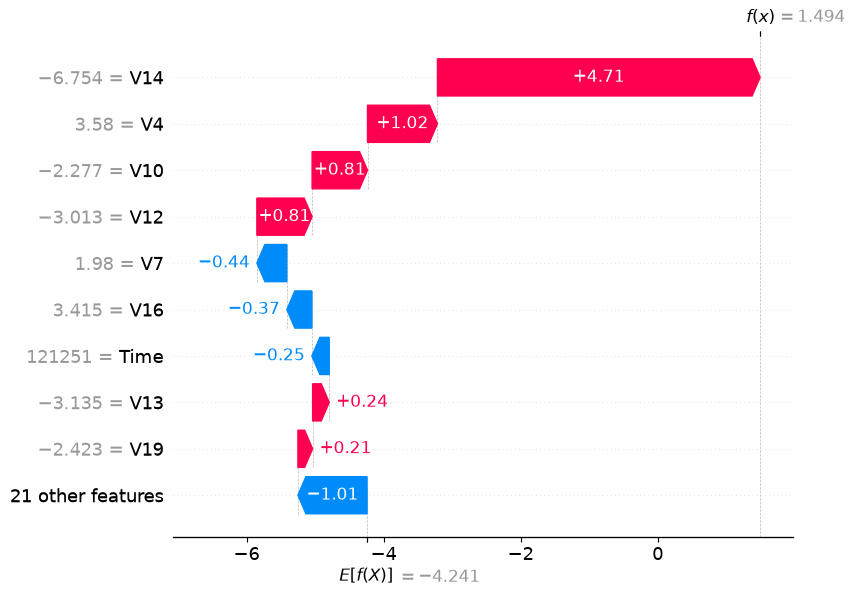

--- SHAP Waterfall: False Positive Fraud Case (Index: 152102) ---


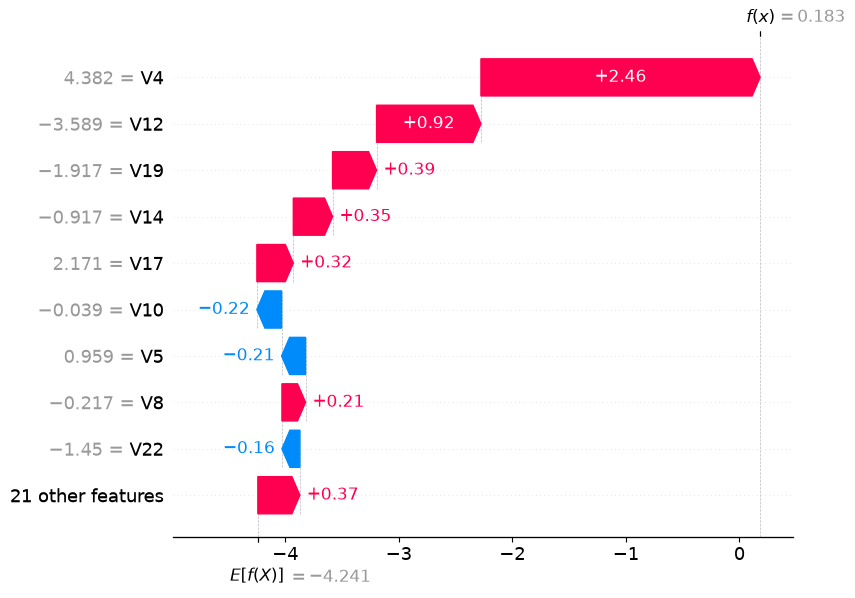

In [9]:
for i in sample_indices_FP:
    pos = X_test.index.get_loc(i)
    print(f"--- SHAP Waterfall: False Positive Fraud Case (Index: {i}) ---")
    shap.plots.waterfall(explanation[pos])

--- SHAP Waterfall: False Negative Fraud Case (Index: 240222) ---


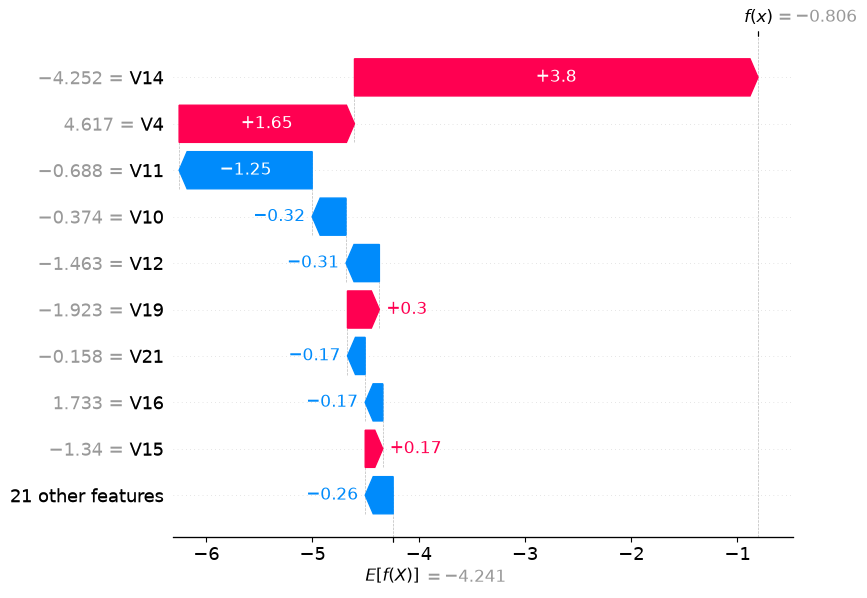

--- SHAP Waterfall: False Negative Fraud Case (Index: 249239) ---


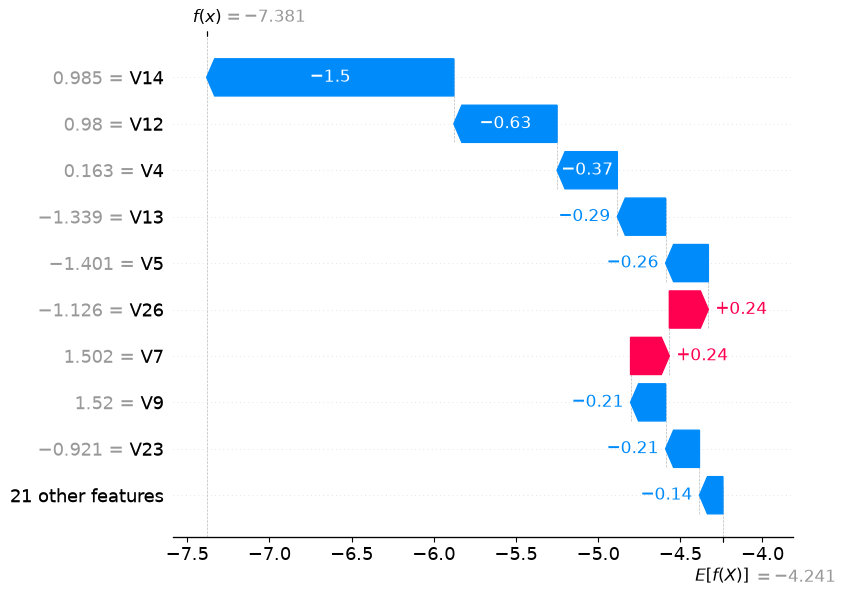

In [10]:
for i in sample_indices_FN:
    pos = X_test.index.get_loc(i)
    print(f"--- SHAP Waterfall: False Negative Fraud Case (Index: {i}) ---")
    shap.plots.waterfall(explanation[pos])